# Validación Estructural del Modelo mediante Descomposición en Valores Singulares (SVD)

Este documento contiene el procedimiento algorítmico para la determinación del rango de la matriz jacobiana asociada al sistema dinámico del Airbus A320. El proceso se divide en las siguientes fases:

1.  **Construcción Simbólica:** Se definen las funciones de restricción cinemática y termodinámica ($g_v, g_{\gamma}, g_m, g_t, g_s$) utilizando la librería `SymPy`. Se realiza el cálculo de las derivadas parciales respecto a las variables de estado y control para los $N-1$ segmentos de la trayectoria discretizada.
2.  **Ensamblaje de la Matriz:** El algoritmo estructura una matriz jacobiana de dimensiones $260 \times 364$, donde cada fila representa una ecuación de igualdad y cada columna una variable del sistema.
3.  **Evaluación Numérica:** Se efectúa la sustitución de los parámetros físicos constantes y de los valores correspondientes a una trayectoria factible de referencia. Este paso transforma la matriz simbólica en una matriz de coeficientes reales de punto flotante.
4.  **Análisis Espectral (SVD):** Se aplica el método de Descomposición en Valores Singulares para extraer los valores singulares ($\sigma_i$) del sistema. Se calcula el umbral de tolerancia técnica basado en el épsilon de la máquina ($\epsilon$) y el valor singular máximo ($\sigma_{max}$).
5.  **Verificación de Independencia Lineal:** El script genera una visualización del espectro singular en escala logarítmica. La presencia de 260 valores singulares con magnitudes situadas por encima del umbral de ruido numérico confirma el rango completo de filas.

Este análisis constituye la evidencia numérica de la independencia funcional de las ecuaciones dinámicas. El resultado valida la aplicación del Teorema de la Función Implícita y fundamenta la reducción del problema a 104 variables independientes (grados de libertad).


In [ ]:
import numpy as np
import sympy
import matplotlib.pyplot as plt

print("Iniciando construcción del Jacobiano")

In [ ]:
# --- 1. DEFINICIÓN DEL SISTEMA SIMBÓLICO  ---
i = sympy.Symbol('i', integer=True)
N = 53
Zp_I = sympy.Symbol('Zp_I')
Zp_F = sympy.Symbol('Zp_F')
v = sympy.Function('v')
gamma = sympy.Function('gamma')
m = sympy.Function('m')
t = sympy.Function('t')
s = sympy.Function('s')
F_N_MCL = sympy.Function('F_N_MCL')
rho = sympy.Function('rho')
Cx_0 = sympy.Symbol('Cx_0')
k = sympy.Symbol('k')
Cz = sympy.Function('Cz')
S_REF = sympy.Symbol('S_REF')
g_0 = sympy.Symbol('g_0')
lambda_ = sympy.Function('lambda_')
eta = sympy.Symbol('eta')
R = sympy.Symbol('R')
L_z = sympy.Symbol('L_z')
Ts_0 = sympy.Symbol('Ts_0')
rho_0 = sympy.Symbol('rho_0')
alpha_0 = sympy.Symbol('alpha_0')

Zp = sympy.Lambda(i, Zp_I + i * (Zp_F - Zp_I) / (N - 1))
rho = sympy.Lambda(i, rho_0*((Ts_0 + L_z*Zp(i))/Ts_0)**(alpha_0 - 1))
F_N_MCL = sympy.Lambda(i, 140000 - 2.53*Zp(i))

# Ecuaciones
g_v = (v(i+1) - v(i))/(Zp(i+1) - Zp(i)) - \
    (1/2) * ( (lambda_(i+1) * F_N_MCL(i+1)) / (m(i+1) * v(i+1) * sympy.sin(gamma(i+1))) - \
            ( (1/2) * rho(i+1) * v(i+1) * S_REF * (Cx_0 + k*Cz(i+1)**2) ) / (m(i+1) * sympy.sin(gamma(i+1))) - \
             g_0 / v(i+1) + \
            (lambda_(i) * F_N_MCL(i)) / (m(i) * v(i) * sympy.sin(gamma(i))) - \
            ( (1/2) * rho(i) * v(i) * S_REF * (Cx_0 + k*Cz(i)**2) ) / (m(i) * sympy.sin(gamma(i))) - \
             g_0 / v(i) )

g_gamma = (gamma(i+1) - gamma(i))/(Zp(i+1) - Zp(i)) - \
    (1/2) * ( ( (1/2)*rho(i+1)*S_REF*Cz(i+1) ) / (m(i+1) * sympy.sin(gamma(i+1))) - \
              g_0 / (v(i+1)**2 * sympy.tan(gamma(i+1))) + \
              ( (1/2)*rho(i)*S_REF*Cz(i) ) / (m(i) * sympy.sin(gamma(i))) - \
              g_0 / (v(i)**2 * sympy.tan(gamma(i))) )

g_m = (m(i+1) - m(i))/(Zp(i+1) - Zp(i)) + \
      (1/2) * eta * ( (lambda_(i+1) * F_N_MCL(i+1)) / (v(i+1) * sympy.sin(gamma(i+1)))  + \
                    (lambda_(i) * F_N_MCL(i)) / (v(i) * sympy.sin(gamma(i))) )

g_t = (t(i+1) - t(i))/(Zp(i+1) - Zp(i)) - \
      (1/2) * ( 1/(v(i+1)*sympy.sin(gamma(i+1))) + 1/(v(i)*sympy.sin(gamma(i))) )

g_s = (s(i+1) - s(i))/(Zp(i+1) - Zp(i)) - \
      (1/2) * ( 1/sympy.tan(gamma(i+1)) + 1/sympy.tan(gamma(i)) )

<>:131: SyntaxWarning: invalid escape sequence '\s'
<>:145: SyntaxWarning: invalid escape sequence '\s'
<>:131: SyntaxWarning: invalid escape sequence '\s'
<>:145: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15967/623134288.py:131: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(range(1, len(S) + 1), S, 'o-', color='#1f77b4', markersize=5, linewidth=1.5, label='Valores Singulares ($\sigma_i$)')
/tmp/ipykernel_15967/623134288.py:145: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Magnitud del Valor Singular ($\sigma_i$)', fontsize=12)


Iniciando construcción del Jacobiano (esto puede tomar 1-2 minutos)...
Calculando Descomposición en Valores Singulares (SVD)...
Generando gráfica...
¡Gráfica guardada con éxito como 'espectro_singular_jacobiano.png'!
Rango reportado por numpy: 260


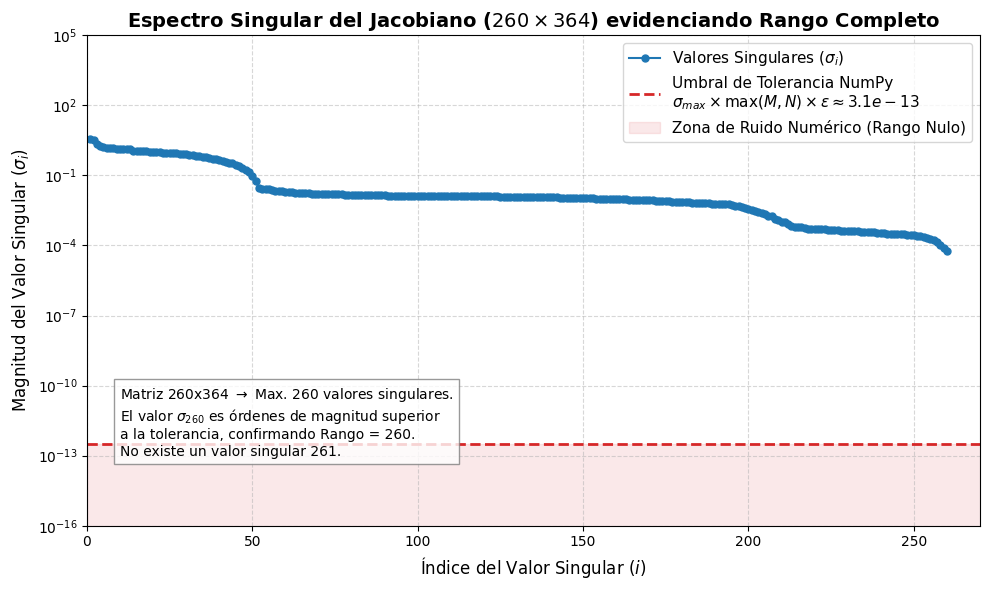

In [ ]:
def derivada_parcial(funcion, variable, i_funcion, i_variable):
    return funcion.subs(i, i_funcion).diff(variable(i_variable)).simplify().trigsimp()

def calcular_jacobiano(N):
    funciones = [g_v, g_gamma, g_m, g_t, g_s]
    variables = [v, gamma, m, t, s, Cz, lambda_]
    num_funciones = len(funciones) * (N - 1)
    num_variables = len(variables) * (N - 1)
    jacobiano = sympy.zeros(num_funciones, num_variables)

    for i_funcion in range(N - 1):
        for j_variable in range(N - 1):
            for k_func, func in enumerate(funciones):
                for l_var, var in enumerate(variables):
                    derivada = derivada_parcial(func, var, i_funcion, j_variable + 1)
                    jacobiano[i_funcion * len(funciones) + k_func, j_variable * len(variables) + l_var] = derivada
    return jacobiano

# --- 2. EVALUACIÓN NUMÉRICA ---
valores_numericos = {
    Zp_I: 10000 * 0.3048, Zp_F: 36000 * 0.3048, Cx_0: 0.014, k: 0.09, S_REF: 120, g_0: 9.80665,
    eta: 0.06 / 3600, R: 287.05287, L_z: -0.0065, Ts_0: 288.15, rho_0: 1.225,
    alpha_0: -9.80665 / (287.05287 * -0.0065)
}

# Vectores de estado de prueba
velo = [136.72, 139.57, 151.95, 137.59, 144.60, 157.97, 165.27, 176.29, 186.22, 201.30, 215.95, 223.48, 210.68, 183.27, 191.76, 215.08, 207.09, 205.43, 206.13, 201.98, 198.12, 196.56, 201.18, 203.90, 208.15, 209.06, 209.39, 211.25, 204.54, 200.98, 205.73, 206.36, 206.32, 208.27, 209.56, 206.63, 205.33, 207.56, 208.41, 208.54, 205.28, 203.74, 209.38, 210.12, 205.27, 206.08, 209.63, 209.82, 208.79, 208.96, 208.70, 209.52]
gammas = [2.35, 1.46, 1.98, 2.04, 1.38, 2.28, 1.79, 2.01, 1.62, 1.75, 1.55, 1.40, 1.38, 1.26, 0.75, 1.16, 1.55, 1.66, 2.47, 2.53, 2.68, 2.02, 2.07, 1.65, 1.60, 2.06, 2.16, 2.12, 1.46, 1.70, 1.87, 2.20, 2.24, 2.03, 2.39, 2.27, 1.65, 1.88, 2.03, 1.78, 1.60, 1.32, 0.88, 1.31, 1.62, 0.86, 0.95, 1.20, 1.06, 0.83, 0.86, 0.42]
eme = [59987, 59948, 59900, 59882, 59838, 59790, 59756, 59718, 59681, 59640, 59601, 59567, 59552, 59548, 59499, 59436, 59415, 59392, 59369, 59354, 59340, 59321, 59295, 59269, 59240, 59217, 59196, 59174, 59158, 59135, 59107, 59085, 59065, 59043, 59022, 59006, 58985, 58959, 58937, 58915, 58894, 58868, 58828, 58793, 58770, 58736, 58693, 58659, 58627, 58588, 58546, 58486]
te = [19.8, 54.1, 89.3, 118.7, 155.3, 188.6, 214.9, 241.4, 267.7, 294.0, 318.8, 345.2, 373.5, 406.6, 454.6, 501.3, 531.7, 557.5, 578.5, 595.3, 611.7, 630.5, 651.5, 674.4, 699.9, 722.6, 742.0, 761.0, 784.8, 811.5, 835.1, 855.7, 874.3, 893.7, 912.3, 930.0, 951.8, 975.4, 996.4, 1018.0, 1042.6, 1071.5, 1110.6, 1149.3, 1177.6, 1214.5, 1260.0, 1298.4, 1334.6, 1378.6, 1427.0, 1499.3]
ese = [2791, 7532, 12616, 16864, 22051, 27025, 31282, 35792, 40559, 45638, 50828, 56630, 62765, 69224, 78278, 87633, 94059, 99385, 103692, 107110, 110392, 114096, 118265, 122906, 128154, 132892, 136945, 140938, 145872, 151299, 156093, 160321, 164164, 168177, 172073, 175743, 180221, 185087, 189458, 193963, 199037, 204950, 213045, 221157, 227048, 234639, 244096, 252144, 259717, 268902, 279005, 294143]
Czz = [0.56, 0.58, 0.48, 0.61, 0.54, 0.50, 0.41, 0.42, 0.32, 0.34, 0.24, 0.28, 0.27, 0.42, 0.35, 0.32, 0.29, 0.37, 0.29, 0.41, 0.32, 0.42, 0.34, 0.40, 0.34, 0.40, 0.34, 0.41, 0.37, 0.47, 0.37, 0.48, 0.37, 0.48, 0.37, 0.50, 0.41, 0.52, 0.40, 0.52, 0.45, 0.55, 0.46, 0.55, 0.48, 0.56, 0.50, 0.57, 0.52, 0.59, 0.55, 0.59]
lamdas = [0.003, 0.98, 0.36, 0.28, 0.94, 0.50, 0.93, 0.66, 0.90, 0.92, 0.96, 0.58, 0.06, 0.06, 0.99, 0.58, 0.23, 0.96, 0.30, 0.86, 0.33, 0.93, 0.79, 0.77, 0.83, 0.63, 0.93, 0.77, 0.35, 0.96, 0.89, 0.79, 0.93, 0.95, 0.93, 0.63, 0.95, 0.95, 0.96, 0.91, 0.68, 0.98, 0.99, 0.73, 0.87, 0.99, 0.98, 0.94, 0.99, 0.99, 0.99, 0.98]

for i_val in range(1, N):
    valores_numericos[v(i_val)] = velo[i_val-1]
    valores_numericos[gamma(i_val)] = gammas[i_val-1]
    valores_numericos[m(i_val)] = eme[i_val-1]
    valores_numericos[t(i_val)] = te[i_val-1]
    valores_numericos[s(i_val)] = ese[i_val-1]
    valores_numericos[Cz(i_val)] = Czz[i_val-1]
    valores_numericos[lambda_(i_val)] = lamdas[i_val-1]

# Condiciones iniciales (i=0)
valores_numericos_0 = {
    v(0): 128.6111, gamma(0): 0.04112, m(0): 60000, t(0): 0, s(0): 0, Cz(0): 0.7309, lambda_(0): 1
}

# --- 3. CÁLCULO DEL JACOBIANO ---
jacobiano_simbolico = calcular_jacobiano(N)
jacobiano_evaluado = jacobiano_simbolico.subs(valores_numericos).subs(valores_numericos_0)

# Convertir a flotantes puros
jac_mat = np.array(jacobiano_evaluado).astype(np.float64)

# --- 4. SVD Y CÁLCULO DE TOLERANCIA ---
print("Calculando Descomposición en Valores Singulares (SVD)...")
# SVD calcula exactamente min(M, N) valores singulares. Aquí min(260, 364) = 260.
S = np.linalg.svd(jac_mat, compute_uv=False)

# Criterio exacto usado por numpy.linalg.matrix_rank
M, N_cols = jac_mat.shape # 260, 364
eps = np.finfo(float).eps # Epsilon de la máquina (~2.22e-16)
tolerancia = S[0] * max(M, N_cols) * eps

# --- 5. GRÁFICA PUBLICACIÓN ---
print("Generando gráfica...")
plt.figure(figsize=(10, 6))

# Plotear valores singulares
plt.plot(range(1, len(S) + 1), S, 'o-', color='#1f77b4', markersize=5, linewidth=1.5, label='Valores Singulares ($\sigma_i$)')

# Plotear línea de tolerancia
plt.axhline(y=tolerancia, color='#d62728', linestyle='--', linewidth=2,
            label=f'Umbral de Tolerancia NumPy\n$\\sigma_{{max}} \\times \\max(M,N) \\times \\epsilon \\approx {tolerancia:.1e}$')

plt.fill_between(range(0, 280), 10**-18, tolerancia, color='#d62728', alpha=0.1, label="Zona de Ruido Numérico (Rango Nulo)")

plt.yscale('log')
plt.xlim(0, 270)
plt.ylim(10**-16, 10**5)

plt.xlabel('Índice del Valor Singular ($i$)', fontsize=12)
plt.ylabel('Magnitud del Valor Singular ($\sigma_i$)', fontsize=12)
plt.title('Espectro Singular del Jacobiano ($260 \\times 364$) evidenciando Rango Completo', fontsize=14, fontweight='bold')

# Anotación en la gráfica
texto_explicativo = (
    "Matriz 260x364 $\\rightarrow$ Max. 260 valores singulares.\n"
    "El valor $\\sigma_{260}$ es órdenes de magnitud superior\n"
    "a la tolerancia, confirmando Rango = 260.\n"
    "No existe un valor singular 261."
)
plt.text(10, 10**-13, texto_explicativo, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()

# Guardar la gráfica
nombre_archivo = "espectro_singular_jacobiano.png"
plt.savefig(nombre_archivo, dpi=300)
print(f"¡Gráfica guardada con éxito como '{nombre_archivo}'!")
print(f"Rango reportado por numpy: {np.linalg.matrix_rank(jac_mat)}")